## Proyecto: Predicción de Spread-F mediante un enfoque multimodal

### Explore data
En este cuaderno se exploran los datos procesados 

In [1]:
import numpy
import matplotlib.pyplot as plt
import os 
import numpy as np
import pandas as pd

from utils import *
from config import * 


cfg = Config()
 

df = pd.read_parquet(os.path.join(cfg.dir_dataset,"data.parquet"))

print(df.head())

                 time  height  value
0 1994-09-29 14:00:00    45.0  0.932
1 1994-09-29 14:00:00    60.0  1.515
2 1994-09-29 14:00:00    75.0  1.514
3 1994-09-29 14:00:00    90.0  1.536
4 1994-09-29 14:00:00   105.0  0.972


### Ploteo de datos
Se plotea dato para un dia en especifico, en el rango de 00-18 LT. El horario a interés de predecir está en el rango de 18LT hasta las 06LT del dia posterior.

t: 216
h: 40
data: (40, 216)


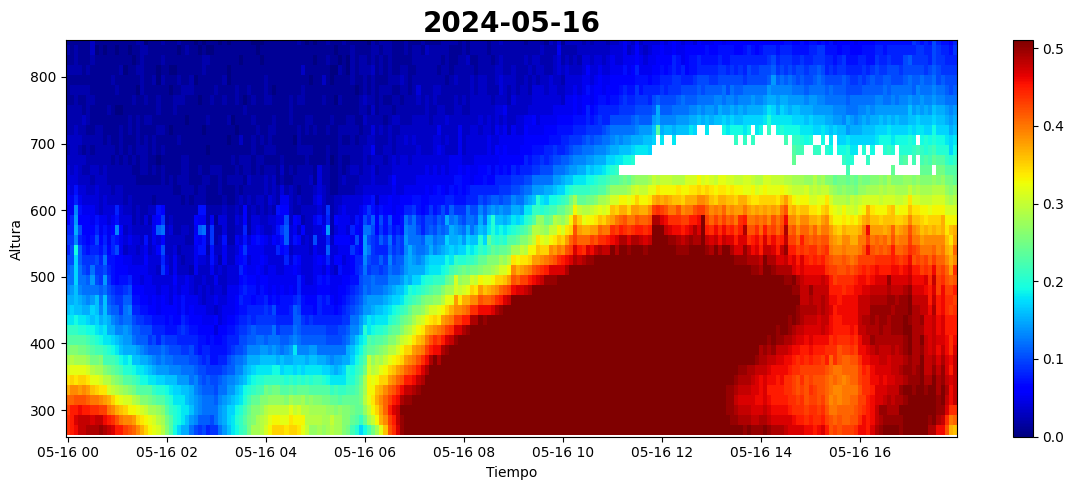

In [2]:
fecha = "2024-05-16"

fecha_init = fecha + " 00:00:00.0"
fecha_fin = fecha + " 17:59:00.0"

t,h,data = retrive_data(df,fecha_init,fecha_fin)

# Verificación opcional
print("t:", len(t))
print("h:", len(h))
print("data:", data.shape)

# ----------------------------------
# PLOT
# ----------------------------------

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 1, 1)
vmax = np.nanpercentile(data, 85)

cc = ax.pcolormesh(
    t,
    h,
    data,
    cmap="jet",
    vmin=0,
    vmax=vmax,
    shading="auto"
)

fig.colorbar(cc, ax=ax)

ax.set_ylim(260, 855)

ax.set_xlabel("Tiempo")
ax.set_ylabel("Altura")

ax.set_title(fecha,fontsize=20,fontweight='bold')

fig.tight_layout()

plt.show()

In [3]:
d_horas = int(((18 - 0) // 18) // (1/12))# cada 3 horas 
d_rango = int(((900 - 250) // 4) // 15 )## tres partchs en altura

#### Patching
Dividimos en patchs de tamaño de 12 x 10 y rellenamos con padding de tipo 'constant'. 
En caso en el patch se cuente que el 50% de los datos dentro del patch son NaN, **se declara como invalido el patch**.

Gracias a esto, es posible crear una máscara de atención para la imagen. A fin de dar menos atención a los patchs que han sido declarados como invalidos.  

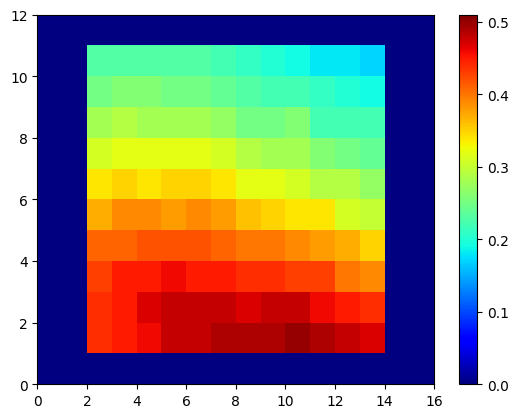

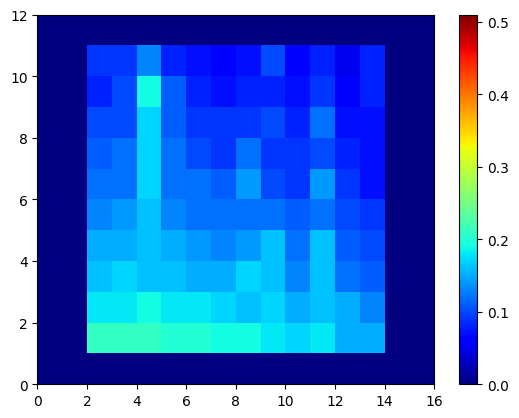

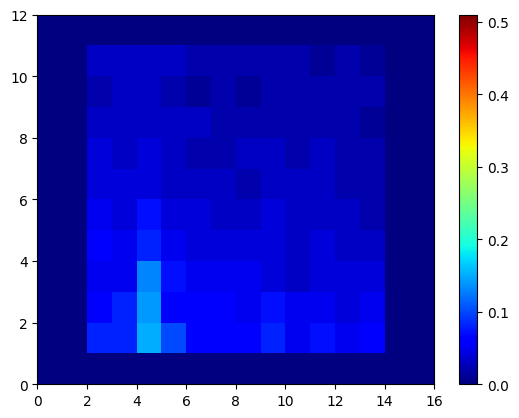

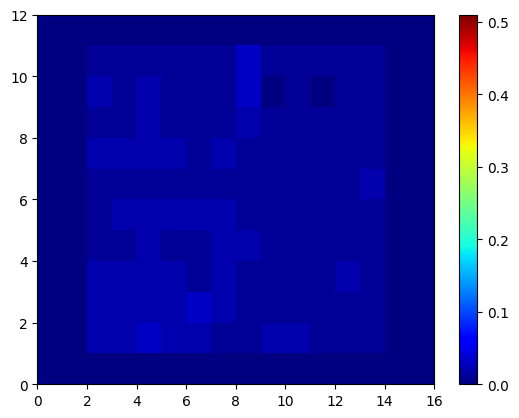

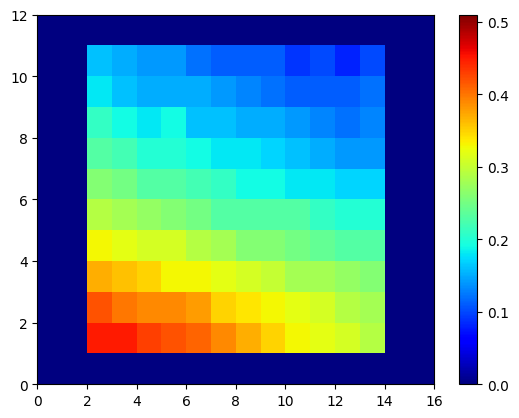

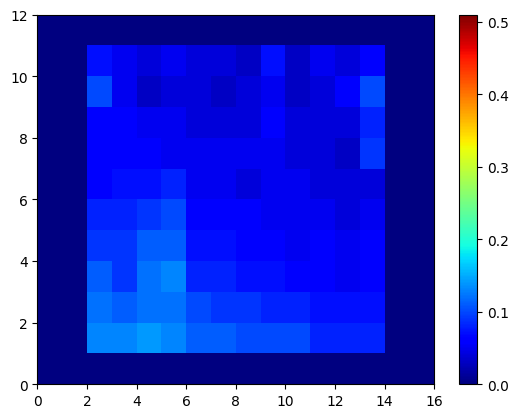

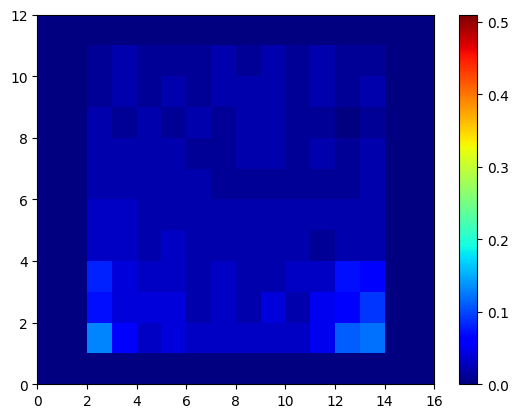

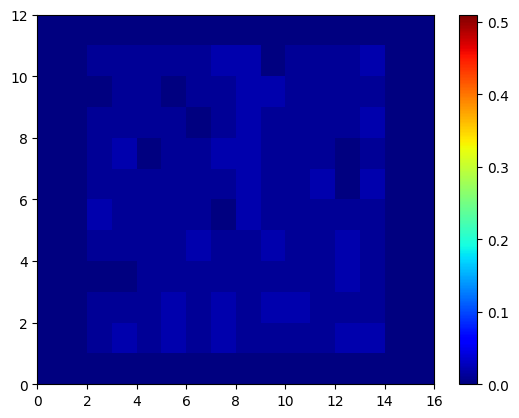

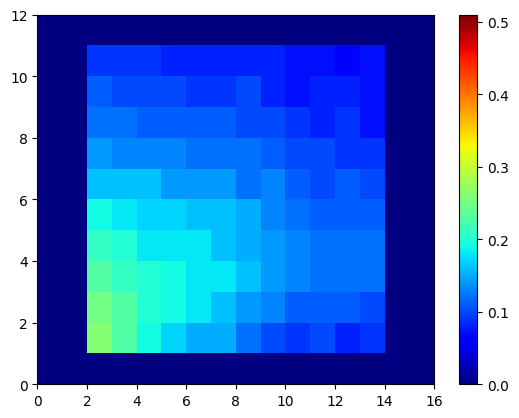

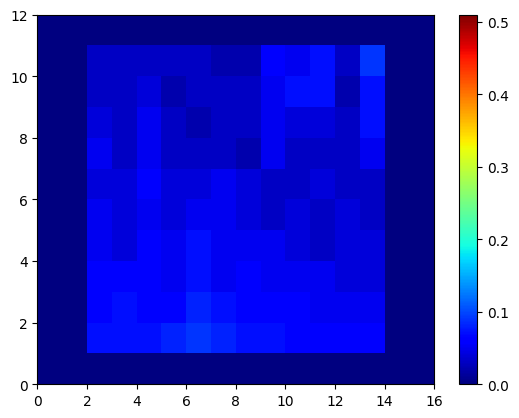

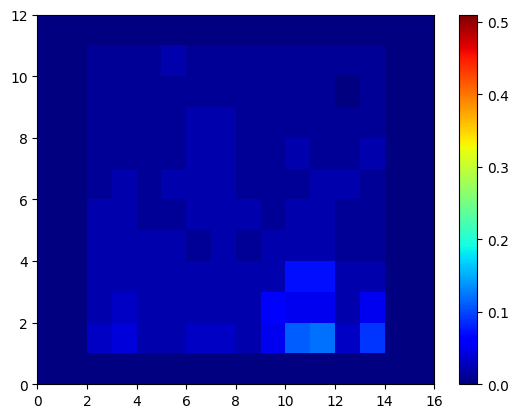

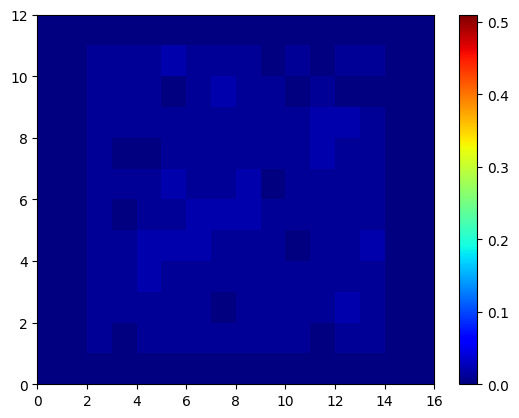

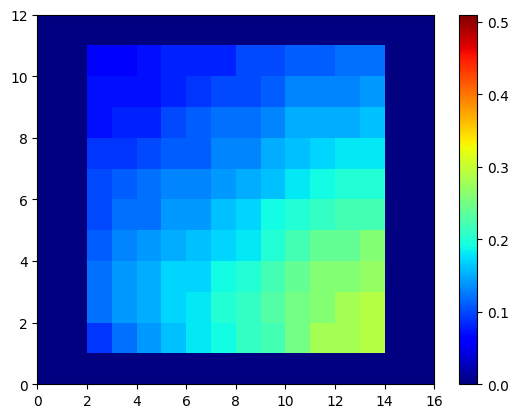

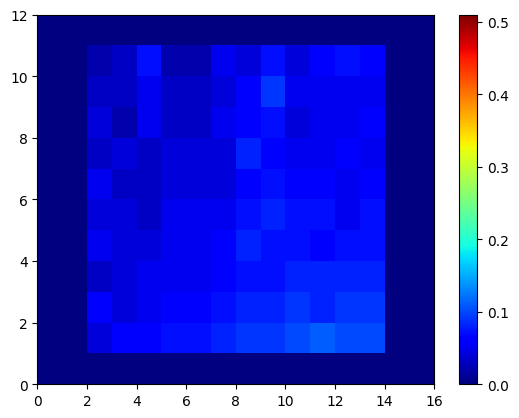

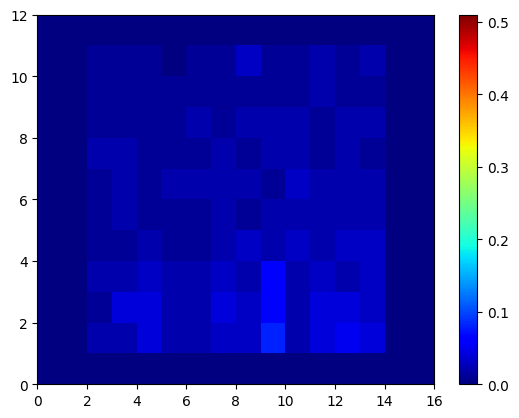

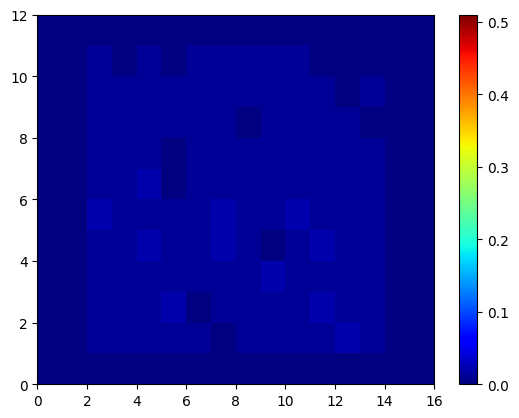

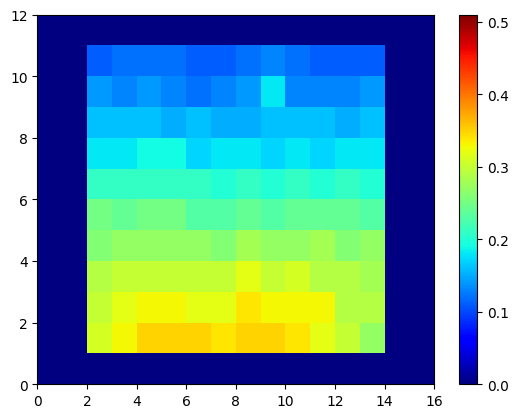

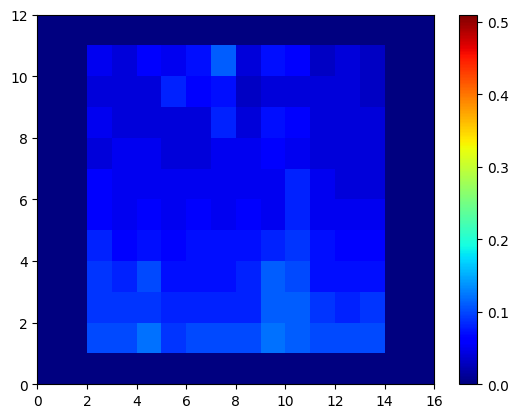

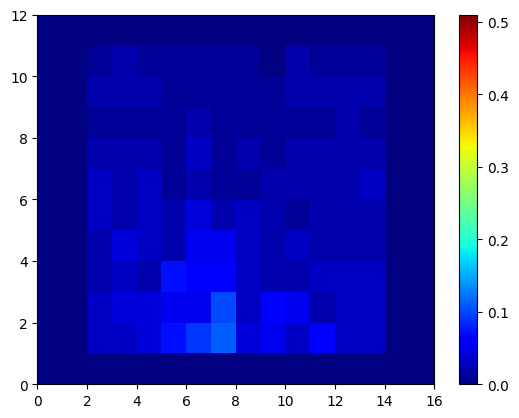

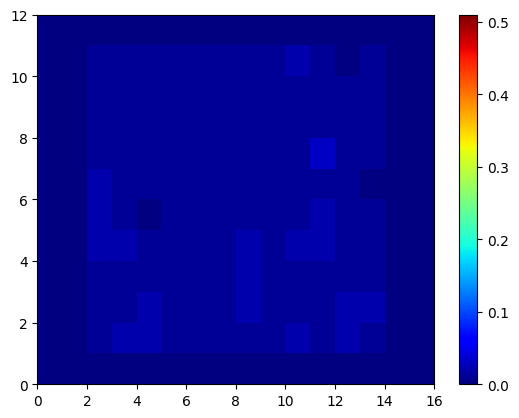

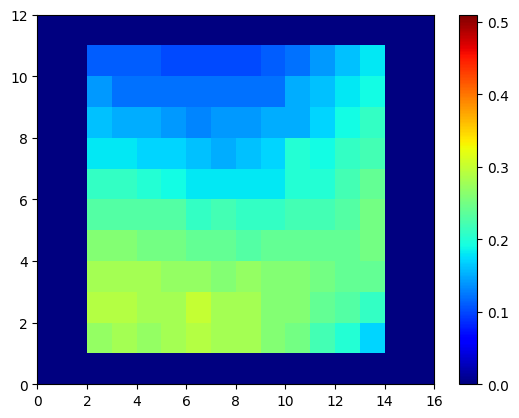

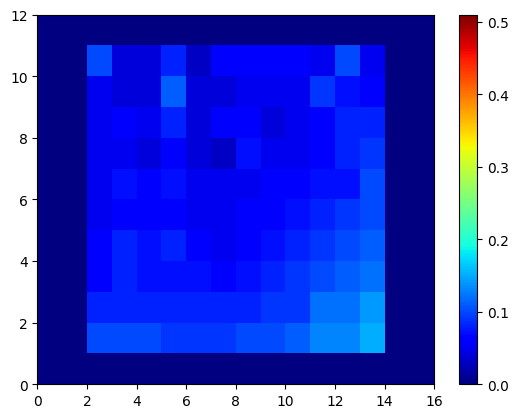

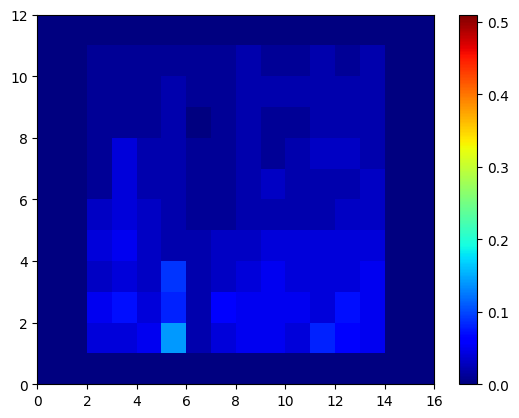

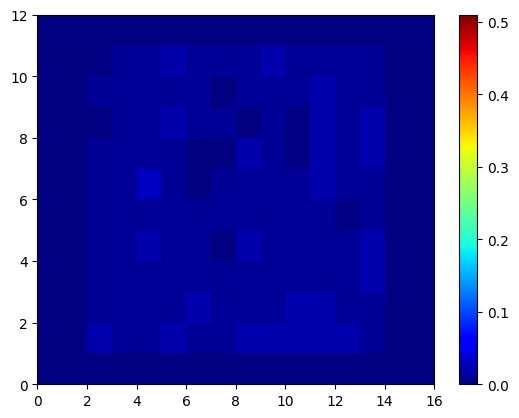

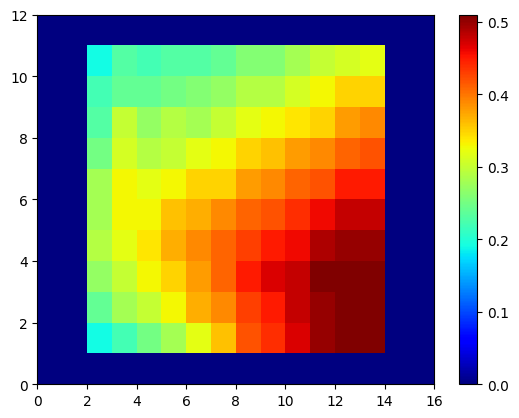

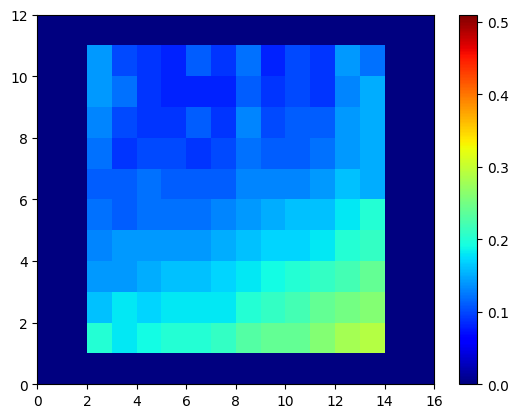

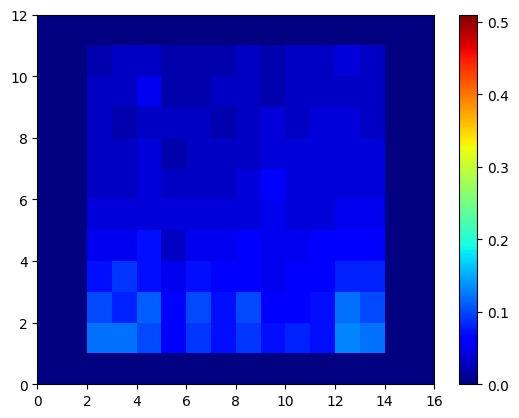

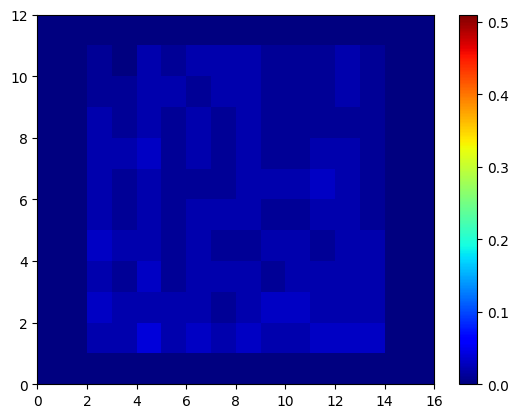

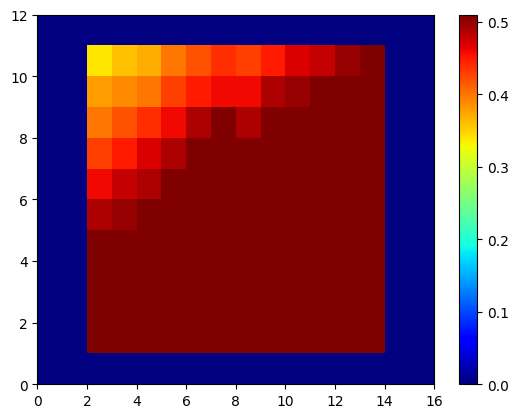

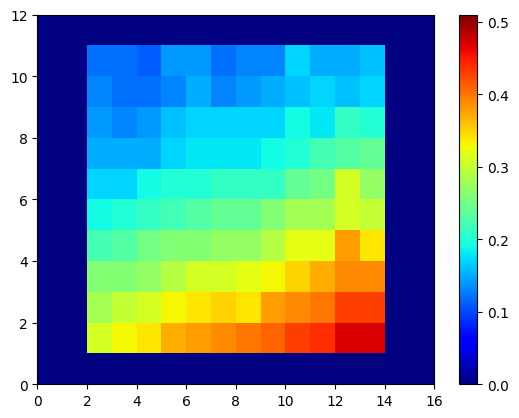

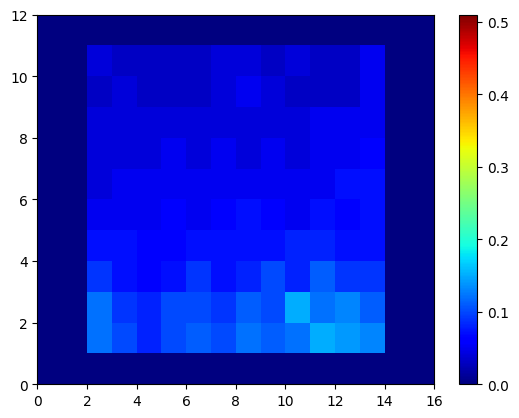

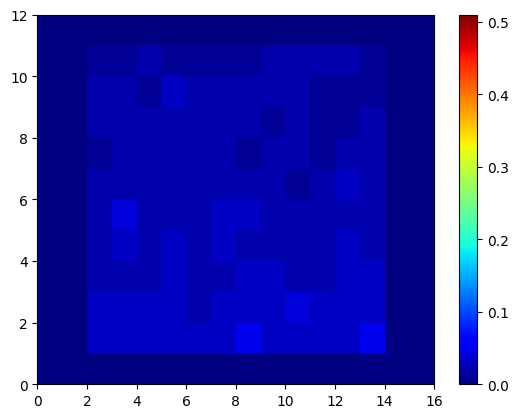

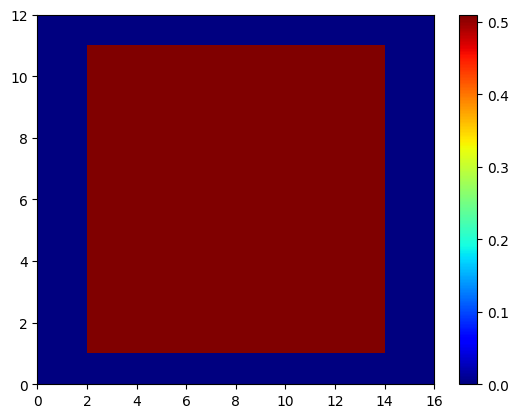

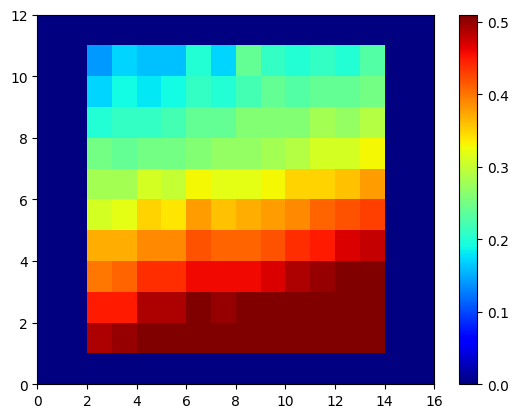

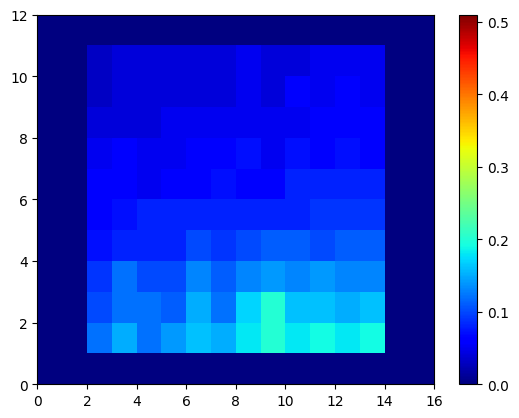

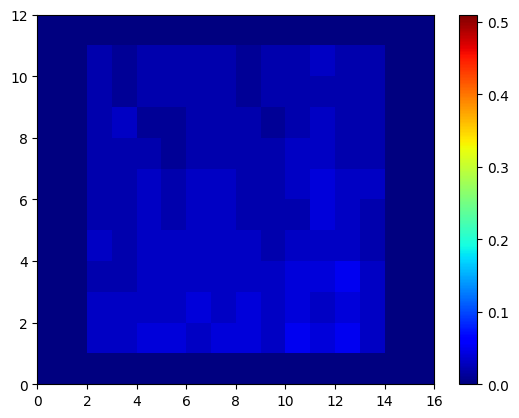

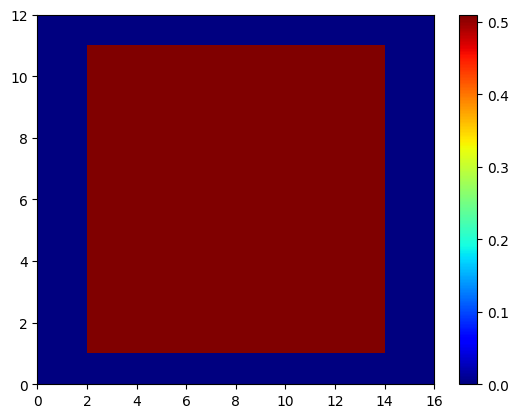

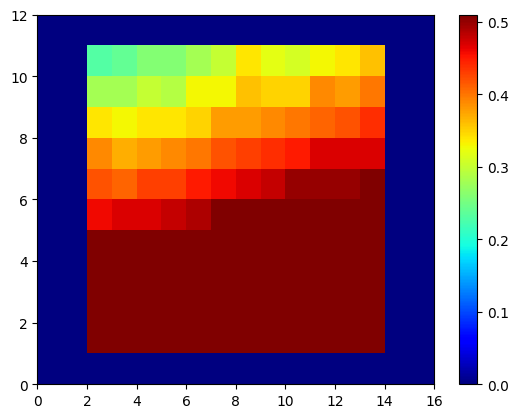

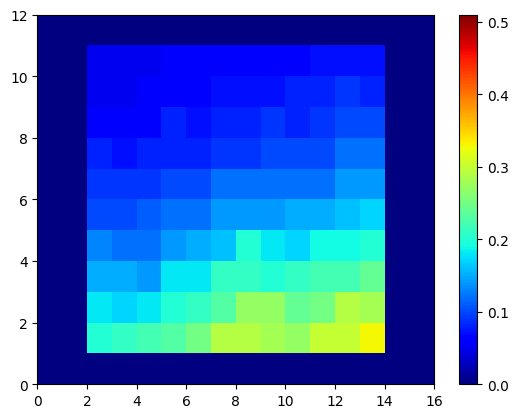

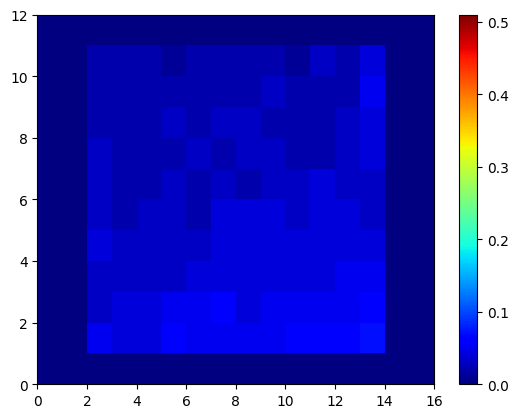

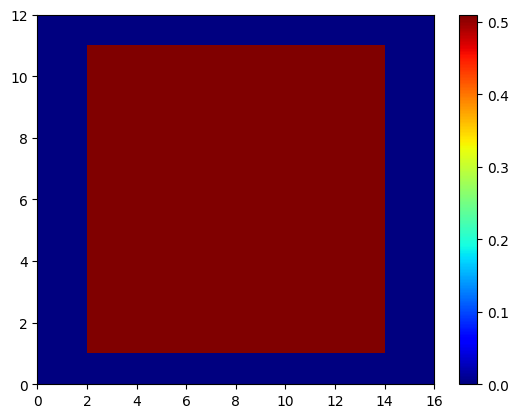

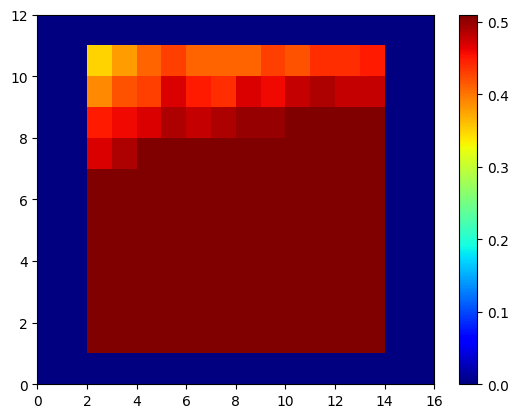

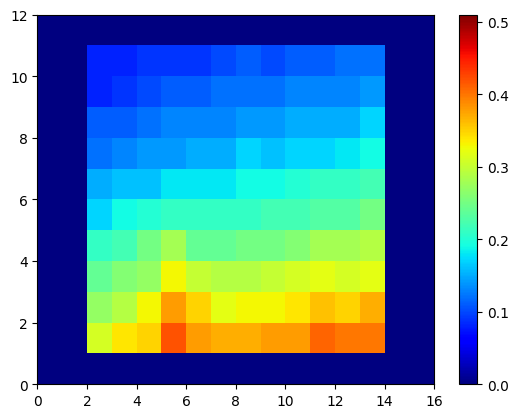

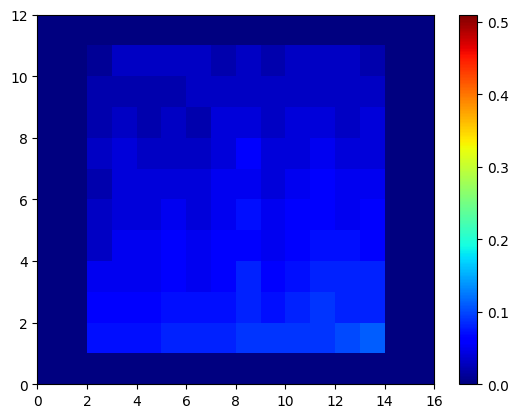

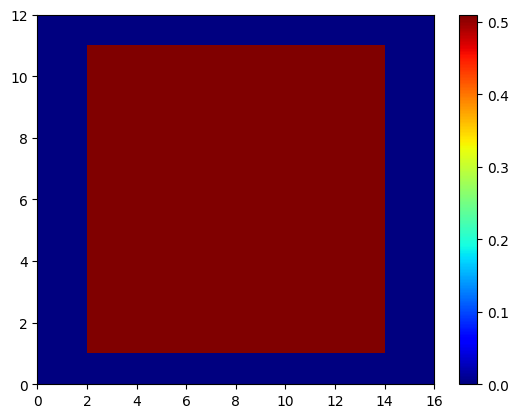

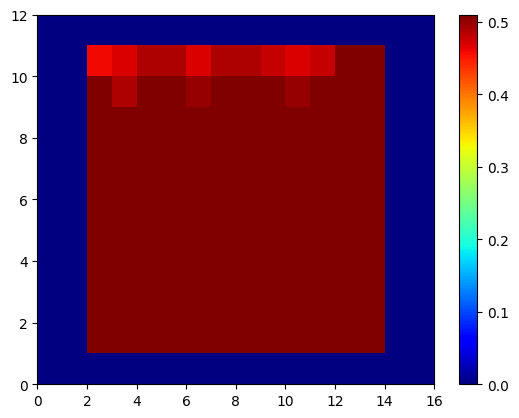

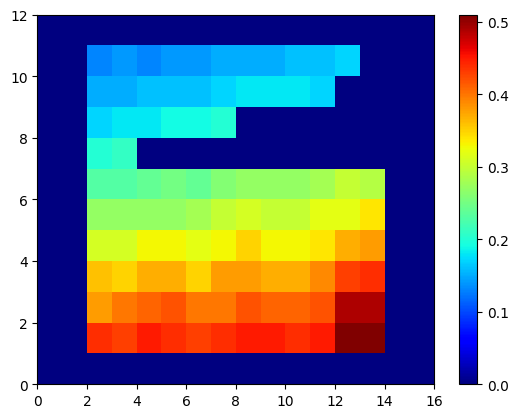

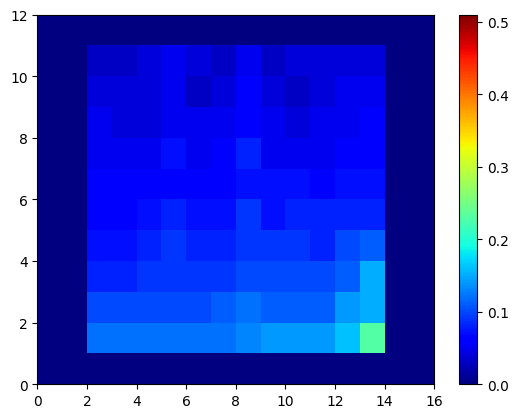

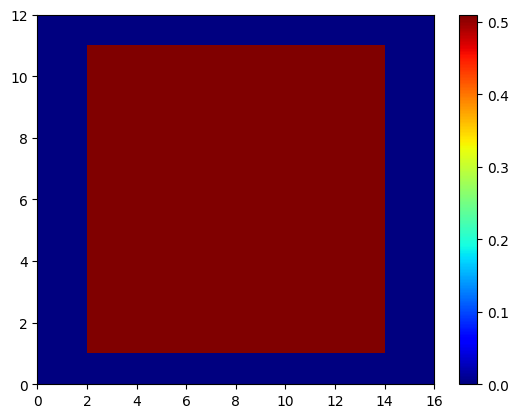

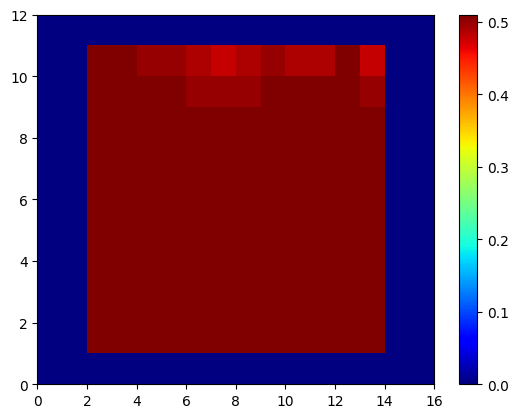

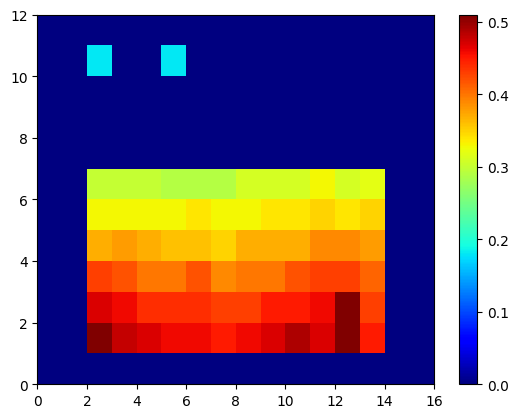

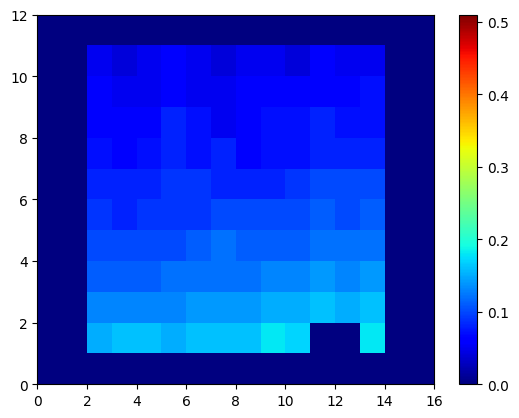

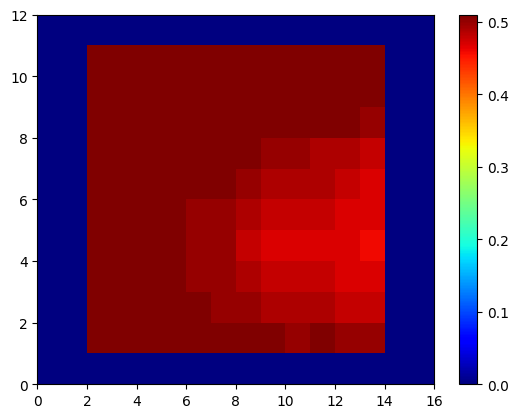

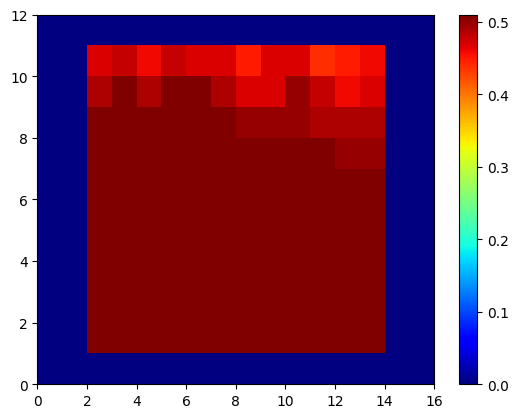

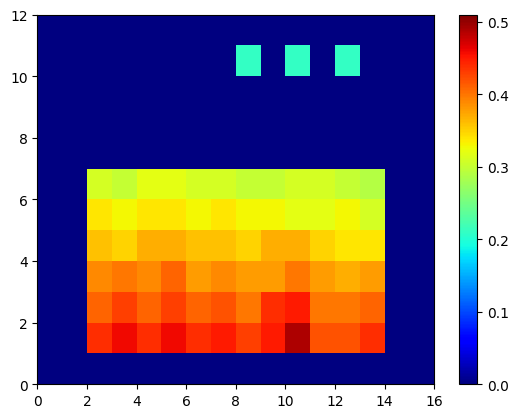

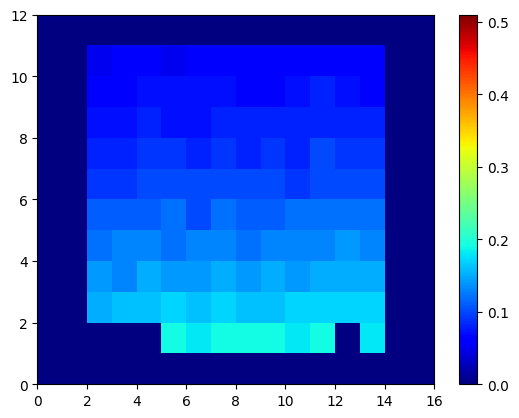

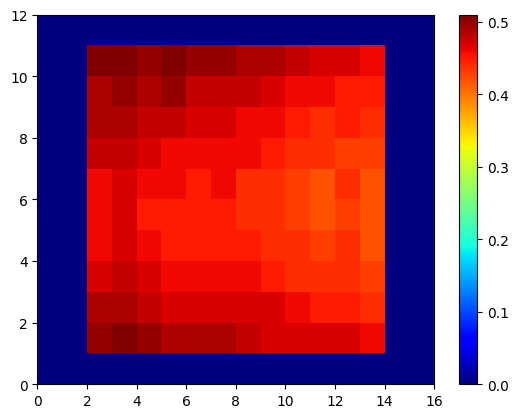

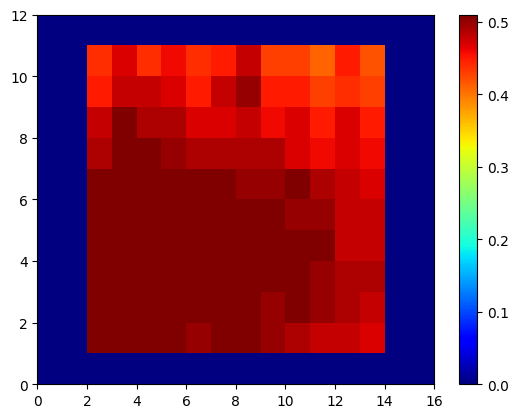

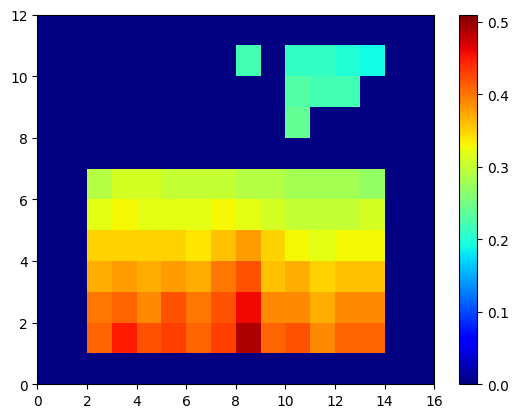

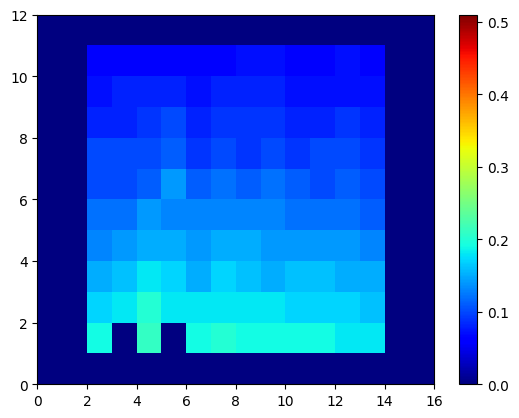

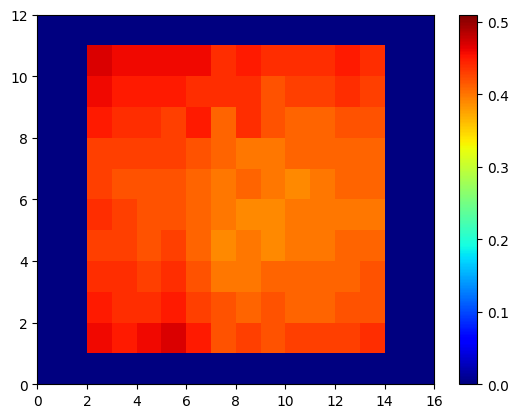

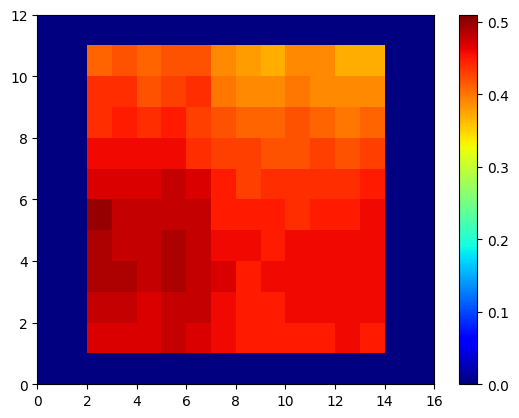

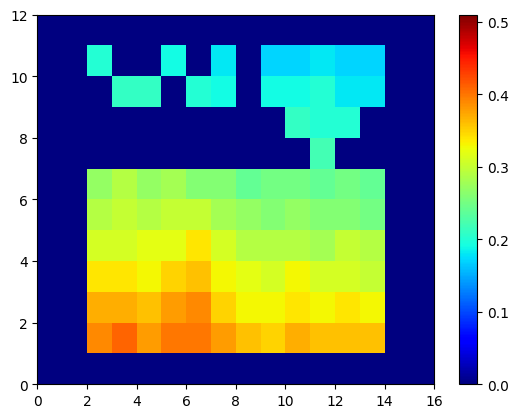

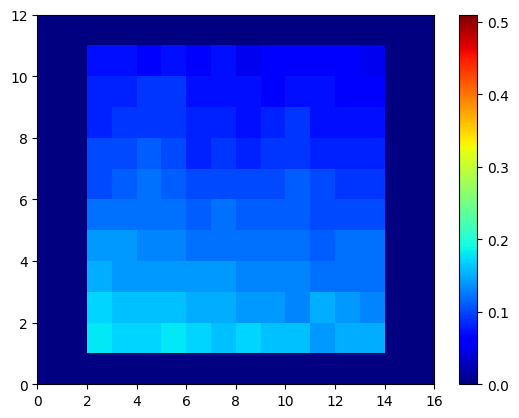

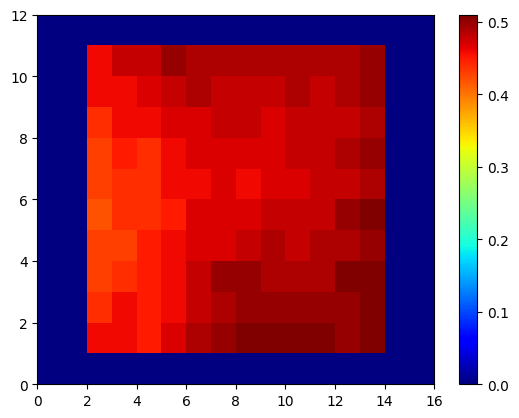

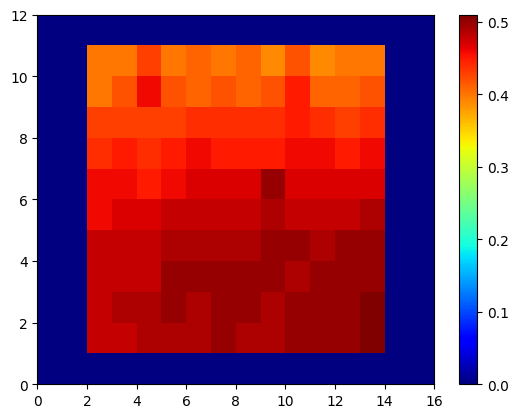

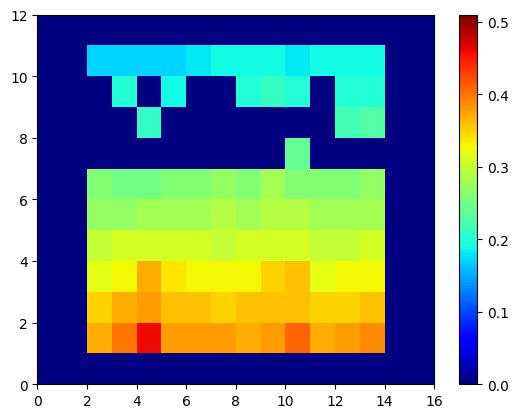

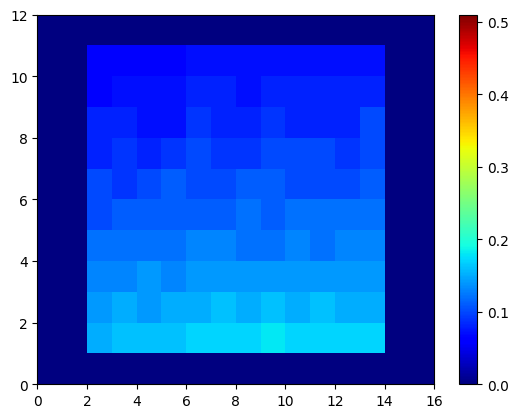

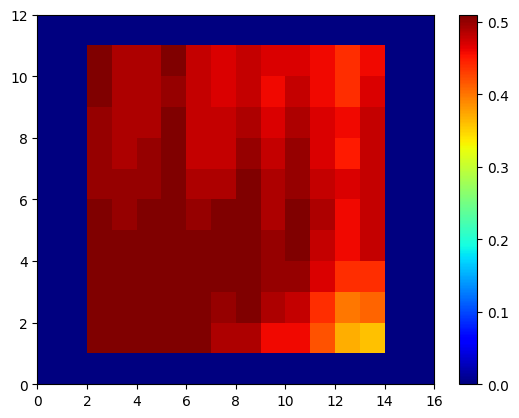

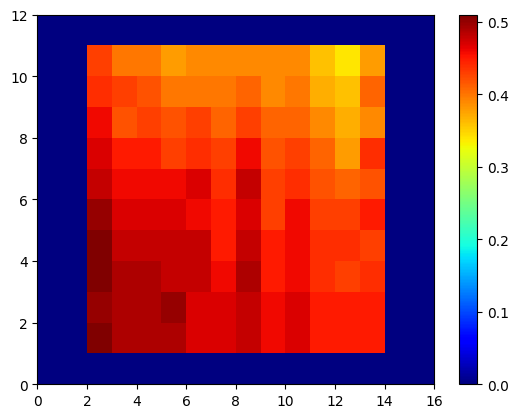

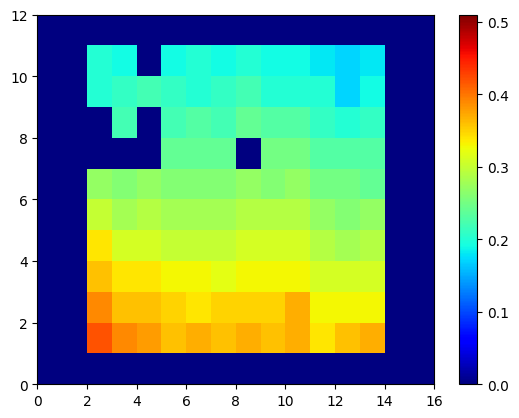

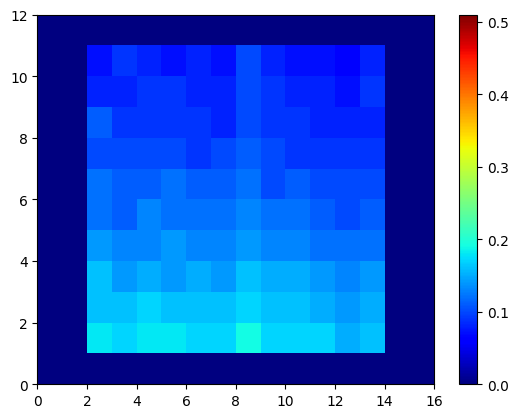

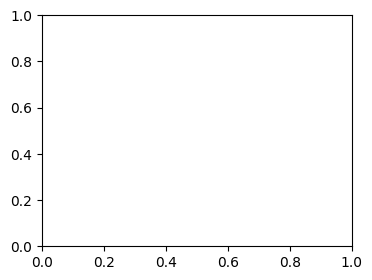

In [12]:
fecha_init = fecha + " 00:00:00.0"
fecha_fin = fecha + " 17:59:00.0"

t,h,data = retrive_data(df,fecha_init,fecha_fin)

patchs = make_patch(t,h,data,d_horas,d_rango)

#tt,hh,patch,_,_,_ = patchs[10]
        
fig = plt.figure(figsize=(4, 3))
ax = fig.add_subplot(1, 1, 1)
vmax = np.nanpercentile(data, 85)
 
for patchz in patchs:
    patch = patchz[2]
  
    fig, ax = plt.subplots()

    cc = ax.pcolormesh(
        patch,
        cmap="jet",
        vmin=0,
        vmax=vmax,
        shading="auto"
    )

    plt.colorbar(cc, ax=ax)

    display(fig)
    plt.close(fig)
    